<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_python_programming/blob/main/miaad_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avance del Proyecto
---
**Título:** Uso problemático de Internet - Child Mind Institute

**Etapas: Métricas de Calidad de los Datos, Análisis Descriptivo y Preprocesamiento**

**Nombre:** Carlos Iván Ramírez Martínez <br>

**Matrícula:** 260499 <br>

**Fecha:** 10/10/2025 <br>

---

# **1) Introducción**
## Child Mind Institute — Problematic Internet Use

El Child Mind Institute es la principal organización sin fines de lucro independiente en salud mental infantil, que proporciona atención de estándar de oro basada en evidencia, ofrece recursos educativos a millones de familias cada año, capacita a educadores en comunidades desatendidas y desarrolla iniciativas de ciencia abierta y tratamientos innovadores para el futuro.

El Healthy Brain Network es una iniciativa de investigación comunitaria del Child Mind Institute que ofrece evaluaciones de salud mental y aprendizaje sin costo a niños y adolescentes elegibles. Al recopilar datos de neuroimagen, fenotípicos y clínicos de miles de jóvenes, estamos construyendo el conjunto de datos más grande jamás realizado del cerebro en desarrollo, y compartimos estos datos desidentificados con la comunidad científica global para mejorar el diagnóstico y el tratamiento desde una perspectiva biológica objetiva.

## Healthy Brain Network  
Un estudio emblemático que ofrece evaluaciones gratuitas de salud mental y aprendizaje a miles de niños y adolescentes, transformando vidas hoy y avanzando la atención de la salud mental juvenil para el futuro.

Las familias con niños de entre 5 y 21 años son elegibles para una evaluación integral de salud mental y aprendizaje sin costo. Las familias aceptan participar en nuestro estudio de investigación completando numerosas evaluaciones exhaustivas.

## Descripcion del Problema
En la era digital actual, el uso problemático de Internet entre niños y adolescentes es una preocupación creciente. Comprender mejor este problema es crucial para abordar problemas de salud mental como la depresión y la ansiedad.

Los métodos actuales para medir el uso problemático de Internet en niños y adolescentes suelen ser complejos y requieren evaluaciones profesionales. Esto crea barreras de acceso, culturales y lingüísticas para muchas familias. Debido a estas limitaciones, el uso problemático de Internet a menudo no se mide directamente, sino que se asocia con problemas como la depresión y la ansiedad en los jóvenes.

Por el contrario, las medidas físicas y de condición física son extremadamente accesibles y ampliamente disponibles con una intervención mínima o experiencia clínica. Los cambios en los hábitos físicos, como una peor postura, dieta irregular y actividad física reducida, son comunes en los usuarios excesivos de tecnología. Proponemos utilizar estos indicadores de condición física fácilmente obtenibles como proxies para identificar el uso problemático de internet, especialmente en contextos que carecen de experiencia clínica o de herramientas de evaluación adecuadas.

Esta competencia te desafía a desarrollar un modelo predictivo capaz de analizar los datos de actividad física de los niños para detectar indicadores tempranos de uso problemático de internet y tecnología. Esto permitirá intervenciones rápidas destinadas a promover hábitos digitales más saludables.

## Acknowledgments
The data used for this competition was provided by the Healthy Brain Network, a landmark mental health study based in New York City that will help children around the world. In the Healthy Brain Network, families, community leaders, and supporters are partnering with the Child Mind Institute to unlock the secrets of the developing brain. In addition to the generous support provided by the Kaggle team, financial support has been provided by the California Department of Health Care Services (DHCS) as part of the Children and Youth Behavioral Health Initiative (CYBHI).

## Importar librerías y Conjunto de datos

In [38]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [39]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [40]:
data_path = '/content/drive/MyDrive/Colab Notebooks/MIAAD/Python_Programming_MIA-0006-24/Proyecto/datos'

#### Leer datos

In [41]:
sample_submission = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))
data_dictionary =  pd.read_csv(os.path.join(data_path, 'data_dictionary.csv'))
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
test = pd.read_csv(os.path.join(data_path, 'test.csv'))
# parquet_files = files[4:]

#### Dictionario de datos
Contiene el significado de cada columna, los valores categoricos o númericos dependiendo de cada columna.

* **instrument:** es una categoría que agrupa diferentes mediciones realizadas a los participantes.
* **field:** es la medición hecha a los participantes, esta representa la informacion capturada para cada instrumento.
* **description:** es una reseña de lo que field representa, en el instrumento psicológico, son las preguntas específicas hechas a los participantes, lo que provee mas información.
* **value y value labels:** representan las etiquetas que podemos encontrar en el dataset para cada instrumento.

In [42]:
# # Normalizaremos los campos Instrument, Field, Description a lower case.
# data_dictionary['Description'] = data_dictionary['Description'].str.lower()
# data_dictionary['Instrument'] = data_dictionary['Instrument'].str.lower()
# data_dictionary['Field'] = data_dictionary['Field'].str.lower()

# # Normalizacion del nombre de columnas del data_dictionary
# dd_old_cols = list(data_dictionary.columns)
# dd_new_cols = [col.lower() for col in dd_old_cols]
# renamed_cols = dict(zip(dd_old_cols, dd_new_cols))
# data_dictionary = data_dictionary.rename(columns=renamed_cols)
# train = train.rename(columns=renamed_cols)

data_dictionary

,Instrument,Field,Description,Type,Values,Value Labels
0,Identifier,id,Participant's ID,str,NaN,NaN
1,Demographics,Basic_Demos-Enroll_Season,Season of enrollment,str,"Spring, Summer, Fall, Winter",NaN
2,Demographics,Basic_Demos-Age,Age of participant,float,NaN,NaN
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"
4,Children's Global Assessment Scale,CGAS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
5,Children's Global Assessment Scale,CGAS-CGAS_Score,Children's Global Assessment Scale Score,int,NaN,NaN
6,Physical Measures,Physical-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
7,Physical Measures,Physical-BMI,Body Mass Index (kg/m^2),float,NaN,NaN
8,Physical Measures,Physical-Height,Height (in),float,NaN,NaN
9,Physical Measures,Physical-Weight,Weight (lbs),float,NaN,NaN


In [43]:
train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,NaN,Fall,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,NaN,Fall,2.340,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.170,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# Data dictionary sub-Dataframes que nos permiten organizar los sub-instrumentos de cada categoria instrument
demographics = data_dictionary.loc[data_dictionary['Instrument'] == 'Demographics']
assesment_scale = data_dictionary.loc[data_dictionary['Instrument'] == "Children's Global Assessment Scale"]
physical_measures = data_dictionary.loc[data_dictionary['Instrument'] == 'Physical Measures']
FGVT = data_dictionary.loc[data_dictionary['Instrument'] == 'FitnessGram Vitals and Treadmill']
FGC = data_dictionary.loc[data_dictionary['Instrument'] == 'FitnessGram Child']
BEIA = data_dictionary.loc[data_dictionary['Instrument'] == 'Bio-electric Impedance Analysis']
PAQA = data_dictionary.loc[data_dictionary['Instrument'] == 'Physical Activity Questionnaire (Adolescents)	']
PAQC = data_dictionary.loc[data_dictionary['Instrument'] == 'Physical Activity Questionnaire (Children)	']
PCIAT = data_dictionary.loc[data_dictionary['Instrument'] == 'Parent-Child Internet Addiction Test	']
SDS = data_dictionary.loc[data_dictionary['Instrument'] == 'Sleep Disturbance Scale	']
IU = data_dictionary.loc[data_dictionary['Instrument'] == 'Internet Use']

# **2) Descripción del dataset**

#### 📌Fuente de los datos:

https://www.kaggle.com/competitions/child-mind-institute-problematic-internet-use/overview

#### 📌Número de registros y variables

In [45]:
print(f"Número de registros: {len(train)}")
print(f"Número de variables: {train.shape[1]}")

Número de registros: 3960
Número de variables: 82


#### 📌Variables principales de interés.

* demographics:
	 - age of participant
	 - sex of participant
* children's global assessment scale:
	 - children's global assessment scale score
* physical measures:
	 - body mass index (kg/m^2)
	 - height (in)
	 - weight (lbs)
	 - waist circumference (in)
	 - diastolic bp (mmhg)
	 - heart rate (beats/min)
	 - systolic bp (mmhg)
* physical activity questionnaire (adolescents):
	 - activity summary score (adolescents)
* physical activity questionnaire (children):
	 - activity summary score (children)
* parent-child internet addiction test:
* sleep disturbance scale:
	 - total raw score
	 - total t-score
* internet use:
	 - hours of using computer/internet

In [46]:
# al ser varias columnas en las que se enlistan los instrumentos de medición utilizados,
# agruparemos estos en grupos que podremos utilizar mas adelante para realizar visualizaciones más concisas
data_group = list(data_dictionary['Instrument'].unique())
data_group = [item.lower() for item in data_group]

# para ver lista completa active los dos print()
for group in data_group:
    # print(f"* {group}:")
    instruments_in_group = list(data_dictionary['Description'].loc[data_dictionary['Instrument'] == group])
    for instrument in instruments_in_group:
      # print(f"\t -{instrument}")
      pass

#### 📌Limitaciones del dataset

No contiene:
  - Desempeño academico de los participantes.
  - Economía familiar.
  - Las encuestas podrían estar sesgadas o no representar la realidad.
  - Contexto social de los participantes.

# **3) Preguntas de análisis descriptivo**

- ¿Cuál es la distribución de la variable objetivo?
- ¿La variable objetivo tiene valores faltantes?
- ¿Cuál es la relación entre la variable objetivo y las variables de interés?
- ¿Cuál es la relación entre la variable objetivo y la actividad física de los participantes?
- ¿Existen valores atípicos en el conjunto de datos?
- ¿Podemos usar las respuestas a encuestas como un indicador fiable para la variable objetivo?
- ¿Es un genero más propenso a tener la variable objetivo alto?
- ¿Cuál es la relación entre la edad y la variable objetivo?
- ¿La estación del año en que la evaluación del participante fue hecha, influye a la variable objetivo?
- ¿Existen participantes que estén duplicados?

# **4) Métricas de calidad de los datos**

#### Completitud (Valores pérdidos)
¿Cuál es la distribución de la variable objetivo?<br>
¿Tiene la variable objetivo valores pérdidos?<br>
¿Será mejor remover los datos pérdidos de la columna objetivo "sii", para comenzar?<br>
Si quitaramos los renglones sii con valores pérdidos ¿Cuántos renglones quedarían?<br>
¿Será que los valores "sii" pérdidos también tienen en otras columnas valores pérdidos, o es un tema aleatorio?<br>
¿Existe desbalance entre las categorías?<br>

In [47]:
df = train.copy()
df_null = df.isnull().sum()

Los valores perdidos de la variable a clasificar, represen el 31%. Cuando el sii es nulo, le siguen casi el mismo número de valores faltantes en otros
instrumentos.

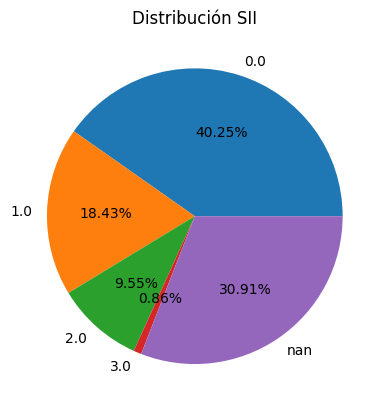

Cantidad de renglones antes de remover nan de la variable objetivo: 3960
Cantidad de renglones antes de remover nan de la variable objetivo: 1224
By removing nan on target column: we lose about 31.9091 % of data


In [48]:
target = train.sii
target_values = list(target.unique())
target_values_count = target.value_counts()
target_nan = target.isnull().sum()

nan_df = pd.DataFrame(
    {'count':[target_nan]}, index=['nan']
)
nan_df

target_values = pd.concat([target_values_count, nan_df])
x = list(target_values.index)
x = [str(x) for x in x]
y = list(target_values['count'])

plt.pie(y, labels = x, autopct="%.2f%%")
plt.title('Distribución SII')
plt.show()

rows_before, column_before = train.shape
print(f"Cantidad de renglones antes de remover nan de la variable objetivo: {rows_before}")
df_target_null = train.loc[train.sii.isnull()]

df_target_not_null = train.loc[train.sii.notnull()]

rows_after, column_after = df_target_null.shape
print(f"Cantidad de renglones antes de remover nan de la variable objetivo: {rows_after}")

print(f"By removing nan on target column: we lose about {1-(rows_after/rows_before) * -100:.4f} % of data")

In [49]:
#Mapa de Calor con Seaborn
# # instruments = demographics_columns, assesment_scale, physical_measures, FGVT, FGC, BEIA, PAQA, PAQC, PCIAT, SDS, IU
def heatmap_missing_data(df, title):
  plt.figure(figsize=(10, 7))
  sns.heatmap(df.isnull(),
              cbar=False,
              cmap='viridis',
              yticklabels=False)
  plt.title(title, fontsize=16, fontweight='bold')
  plt.xlabel('Columnas del DataFrame', fontsize=13)
  plt.tight_layout()  # Mejora la distribución del gráfico
  plt.show()

**Visualización de Datos Perdidos Totales**

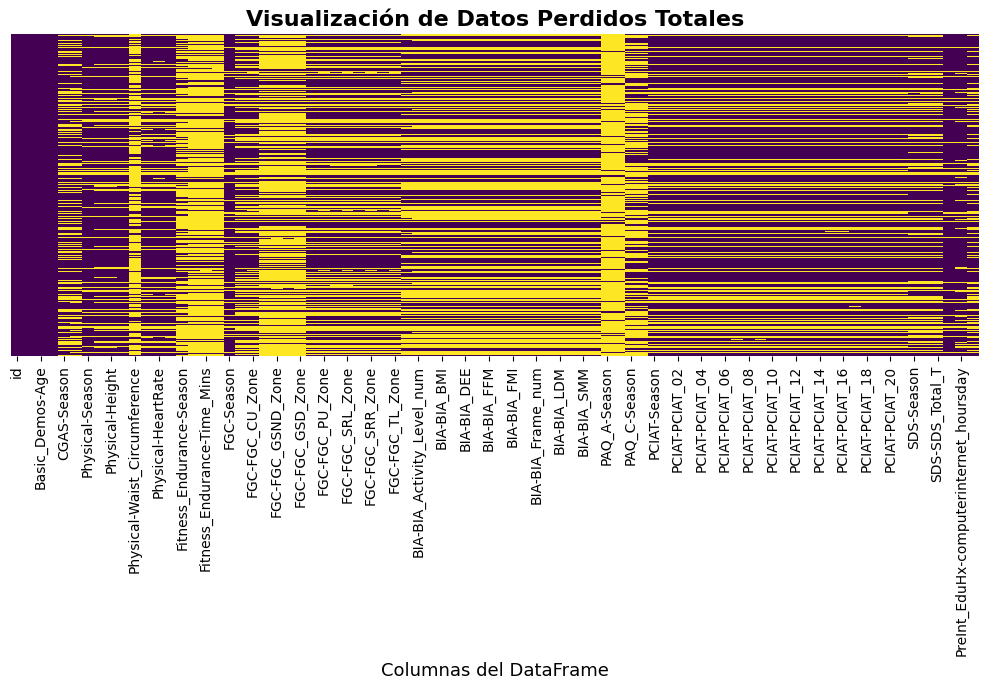

In [50]:
heatmap_missing_data(train, 'Visualización de Datos Perdidos Totales')


**Visualización de Datos Perdidos cuando 'sii' es nulo**

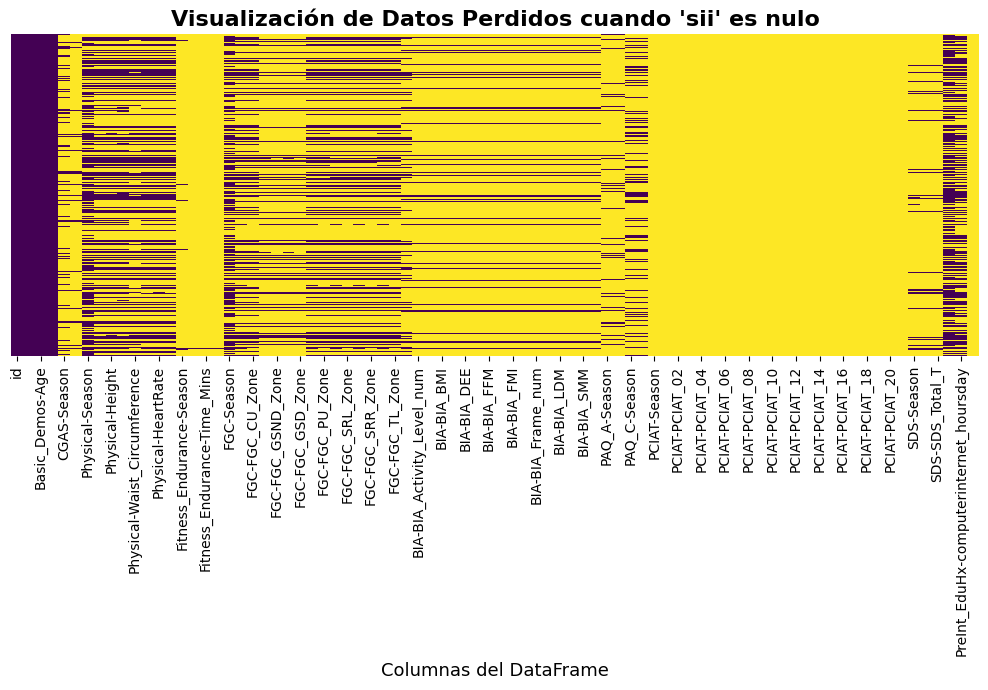

In [51]:
heatmap_missing_data(df_target_null, "Visualización de Datos Perdidos cuando 'sii' es nulo")

**Visualización de Datos Perdidos cuando 'sii' es nulo**

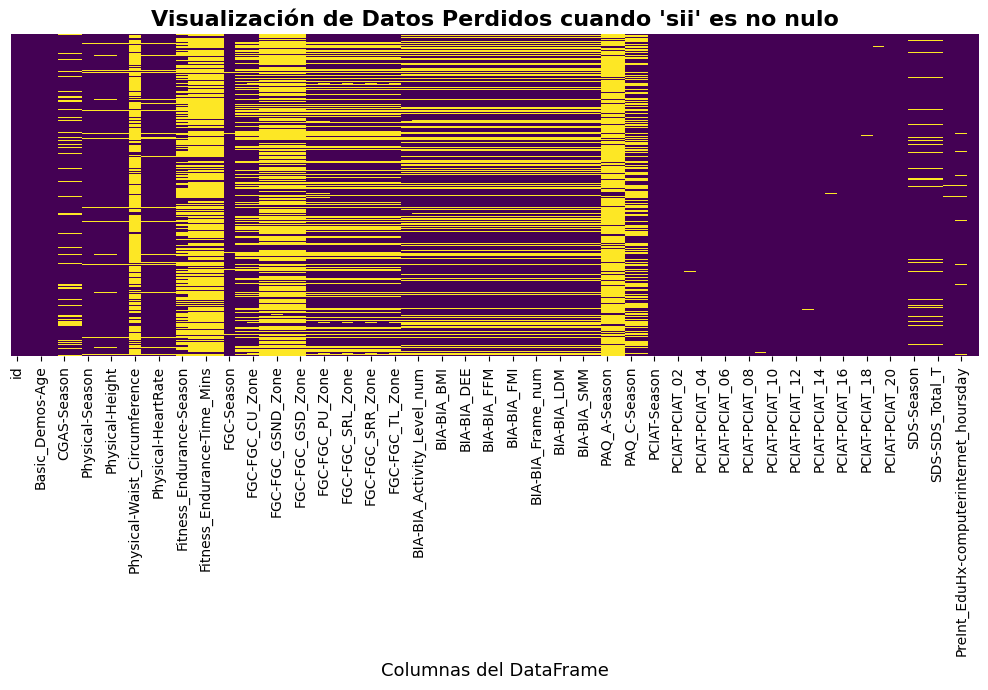

In [52]:
heatmap_missing_data(df_target_not_null, "Visualización de Datos Perdidos cuando 'sii' es no nulo")

#### Consistencia

In [53]:
data_dictionary

,Instrument,Field,Description,Type,Values,Value Labels
0,Identifier,id,Participant's ID,str,NaN,NaN
1,Demographics,Basic_Demos-Enroll_Season,Season of enrollment,str,"Spring, Summer, Fall, Winter",NaN
2,Demographics,Basic_Demos-Age,Age of participant,float,NaN,NaN
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"
4,Children's Global Assessment Scale,CGAS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
5,Children's Global Assessment Scale,CGAS-CGAS_Score,Children's Global Assessment Scale Score,int,NaN,NaN
6,Physical Measures,Physical-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
7,Physical Measures,Physical-BMI,Body Mass Index (kg/m^2),float,NaN,NaN
8,Physical Measures,Physical-Height,Height (in),float,NaN,NaN
9,Physical Measures,Physical-Weight,Weight (lbs),float,NaN,NaN


#### Unicidad

In [54]:
duplicates = df.duplicated()
print(f" Cuenta de participantes duplicados: {duplicates.sum()}")

 Cuenta de participantes duplicados: 0


#### Validez (Rangos adecuados)

In [55]:
df.describe()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
count,3960.000000,3960.000000,2421.000000,3022.000000,3027.000000,3076.000000,898.000000,2954.000000,2967.000000,2954.000000,743.000000,740.000000,740.000000,2322.000000,2282.000000,1074.000000,1062.000000,1074.000000,1063.000000,2310.000000,2271.000000,2305.000000,2267.000000,2307.000000,2269.000000,2324.000000,2285.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.00000,1991.000000,1991.000000,1991.000000,475.000000,1721.000000,2733.000000,2734.000000,2731.000000,2731.000000,2729.000000,2732.000000,2729.000000,2730.000000,2730.000000,2733.000000,2734.000000,2731.000000,2729.000000,2732.000000,2730.000000,2728.000000,2725.000000,2728.000000,2730.000000,2733.000000,2736.000000,2609.000000,2606.000000,3301.000000,2736.000000
mean,10.433586,0.372727,65.454771,19.331929,55.946713,89.038615,27.278508,69.648951,81.597236,116.983074,4.989233,7.370270,27.581081,11.259690,0.476337,22.420438,1.829567,23.518622,1.904045,5.579654,0.330251,8.694924,0.618880,8.805635,0.620097,9.252775,0.785558,2.651431,6.719826,19.367048,1237.018187,2064.693747,20.825346,74.021708,15.030554,4.336495,16.855020,1.745354,33.173380,20.02299,67.301883,34.389466,53.998726,2.178853,2.589550,2.370655,2.177762,2.399854,0.839253,2.297545,1.063690,0.586295,1.246520,1.062637,1.304793,1.685443,0.244599,1.340051,1.035505,1.499634,1.452346,1.627890,1.613636,1.158974,0.943652,27.896199,41.088923,57.763622,1.060588,0.580409
std,3.574648,0.483591,22.341862,5.113934,7.473764,44.569040,5.567287,13.611226,13.665196,17.061225,2.014072,3.189662,17.707751,11.807781,0.499549,10.833995,0.612585,11.148951,0.612344,7.390161,0.470407,3.429301,0.485769,3.422167,0.485469,2.988863,0.410525,1.028267,92.586325,5.047848,1872.383246,2836.246272,73.266287,199.433753,5.792505,6.356402,199.372119,0.680635,56.272346,70.21561,108.705918,84.050607,129.362539,0.849476,0.783937,1.673312,1.697117,1.588807,1.195601,1.705218,1.268282,1.049355,1.342582,1.258797,1.331715,1.543074,0.522956,1.411156,1.301712,1.492929,1.495600,1.445622,1.529178,1.343661,1.185460,20.338853,10.427433,13.196091,1.094875,0.771122
min,5.000000,0.000000,25.000000,0.000000,33.000000,0.000000,18.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-7.789610,0.048267,813.397000,1073.450000,1.789450,28.900400,7.864850,-194.163000,-8745.080000,1.000000,14.489000,4.63581,23.620100,4.655730,20.589200,0.660000,0.580000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,38.000000,0.000000,0.000000
25%,8.000000,0.000000,59.000000,15.869350,50.000000,57.200000

In [56]:
df.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,NaN,Fall,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,NaN,Fall,2.340,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.170,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
cols_of_interest = list(demographics['Field'])
df[cols_of_interest].head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex
0,Fall,5,0
1,Summer,9,0
2,Summer,10,1
3,Winter,9,0
4,Spring,18,1


### Conclusiones:
**Completitud:** Al observar los mapas de calor de los valores faltantes, cuando sii presenta valores nulos las demas columnas también presentan valores faltantes, especial enfásis en aquellas relacionadas con el cuestionario psicológico, estan completamente faltantes también. Esto me da la idea de que los participantes dejaron de asistir a las pruebas siguientes y no se pudo realizar la evaluacion completa del sii.

**Consistencia:** Los tipos de datos son correctos y están en los formatos esperados, sólo faltaría convertir a variables ordinales la estación del año en que fueron evaluados los participantes en caso de que exista una relación con la variable objetivo.

**Unicidad:** No existen duplicados en el conjunto de datos.

**Validez:** El rango de las mediciones parece el adecuado para la mayoría de los participantes, existe uno o dos participantes que sus edades superan los 18 años, estos dos podrían crear outliers respecto al grueso de los participantes cuya media 10 años y +/- 1std es de ~3.5, estos participantes podrían diferenciarse mucho de los participantes cerca de la media quienes por ser más pequeños sus mediciones son distintas.

# **5) Análisis descriptivo de los datos**

In [58]:
# Data dictionary sub-Dataframes que nos permiten organizar los sub-instrumentos de cada categoria instrument
# demographics, assesment_scale, physical_measures, FGVT, FGC, BEIA, PAQA, PAQC, PCIAT, SDS, IU

# Crear los gráficos de PDF e Histograma
def hist_pdf_plot(df, sub_df):
  cols_sub_df_list = list(sub_df['Field'])
  filtered_columns = [col for col in cols_sub_df_list if 'Season' not in col]
  dfp = df[filtered_columns]

  plt.figure(figsize=(12, 10))
  for i, col in enumerate(filtered_columns, 1):
      plt.subplot(4, 4, i)  # Ajustar la cantidad de subgráficos según el número de columnas
      sns.histplot(dfp[col], kde=True, bins=50)
      plt.title(f'{i-1}: {col}', fontsize=12)
      plt.xlabel(col)
      plt.ylabel('Frecuencia')

  plt.tight_layout()
  plt.show()

# Crear los gráficos de PDF e Histograma
def box_plot(df, sub_df):
  cols_sub_df_list = list(sub_df['Field'])
  filtered_columns = [col for col in cols_sub_df_list if 'Season' not in col]
  dfp = df[filtered_columns]

  plt.figure(figsize=(12, 10))
  for i, col in enumerate(filtered_columns, 1):
      plt.subplot(4, 4, i)  # Ajustar la cantidad de subgráficos según el número de columnas
      sns.boxplot(dfp[col], orient='h')
      plt.title(f'{i-1}: {col}', fontsize=12)
      plt.xlabel(col)
      plt.ylabel('Frecuencia')

  plt.tight_layout()
  plt.show()

Instruments: demographics, assesment_scale, physical_measures, FGVT, FGC, BEIA, PAQA, PAQC, PCIAT, SDS, IU

In [59]:
def plot_histograms_and_box_plots(df):
  hist_pdf_plot(df, demographics)
  box_plot(df, demographics)
  hist_pdf_plot(df, physical_measures)
  box_plot(df, physical_measures)
  hist_pdf_plot(df, assesment_scale)
  box_plot(df, assesment_scale)
  hist_pdf_plot(df, FGVT)
  box_plot(df, FGVT)
  hist_pdf_plot(df, FGC)
  box_plot(df, FGC)
  hist_pdf_plot(df, BEIA)
  box_plot(df, BEIA)
  hist_pdf_plot(df, PAQA)
  box_plot(df, PAQA)
  hist_pdf_plot(df, PAQC)
  box_plot(df, PAQC)
  hist_pdf_plot(df, PCIAT)
  box_plot(df, PCIAT)
  hist_pdf_plot(df, SDS)
  box_plot(df, SDS)
  hist_pdf_plot(df, IU)
  box_plot(df, IU)

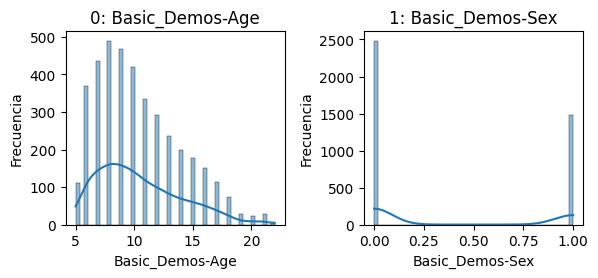

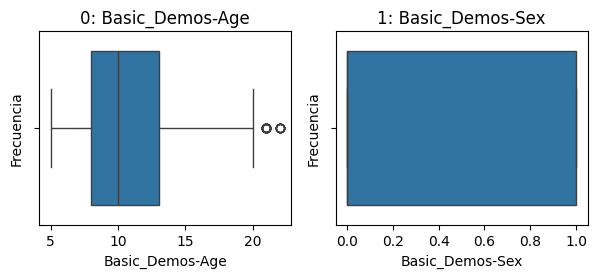

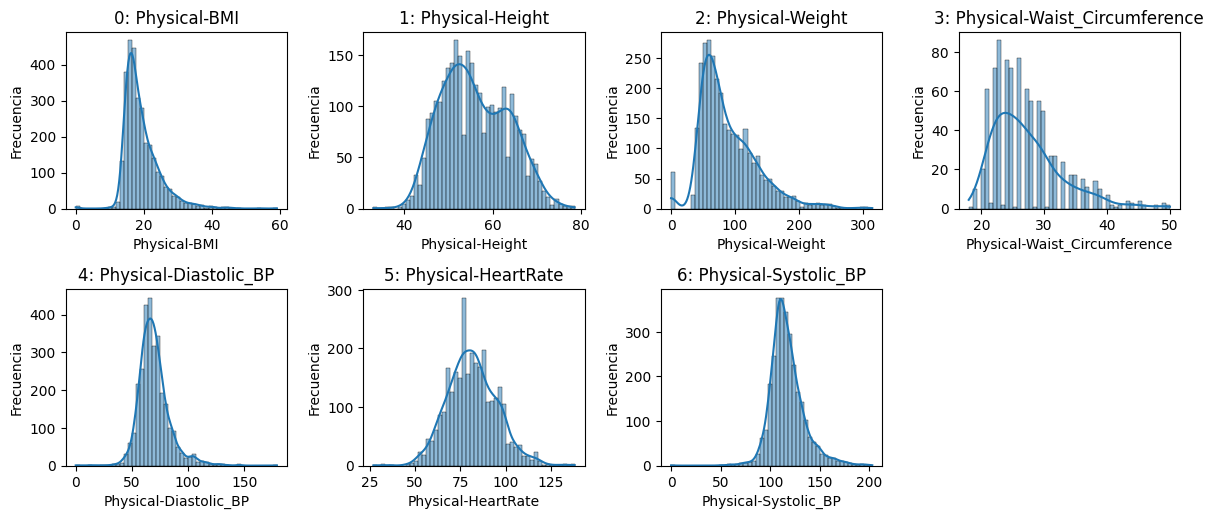

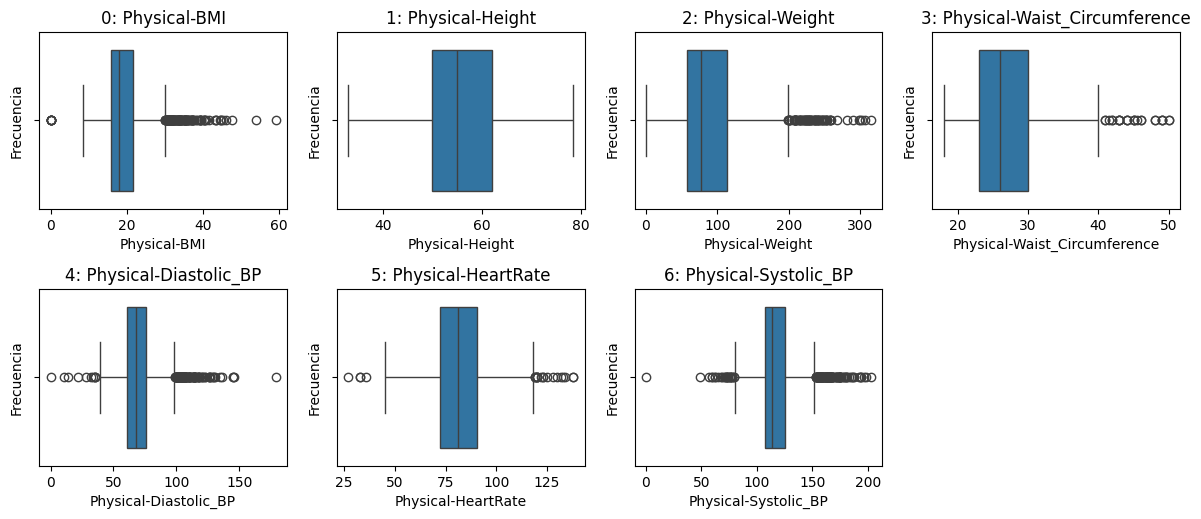

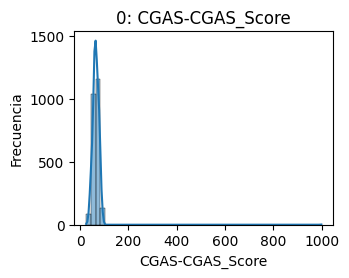

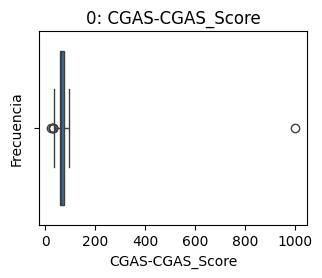

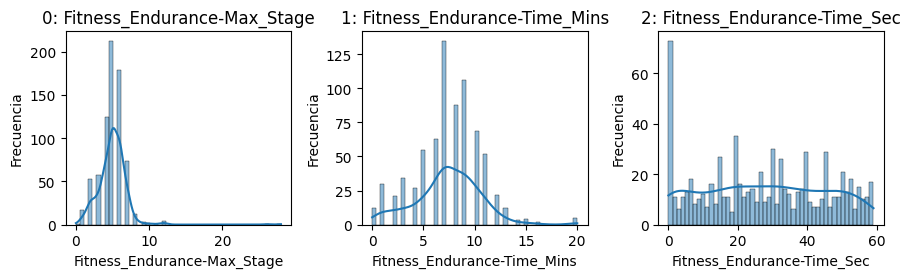

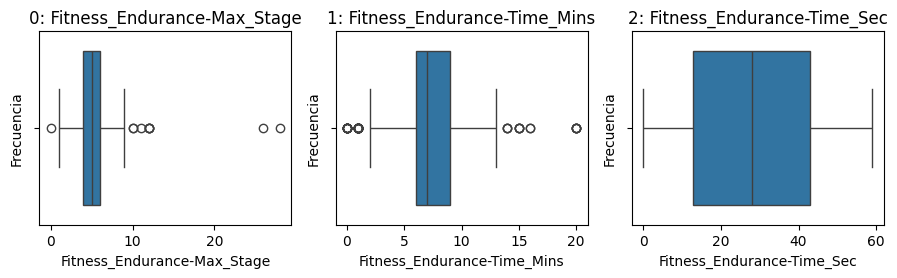

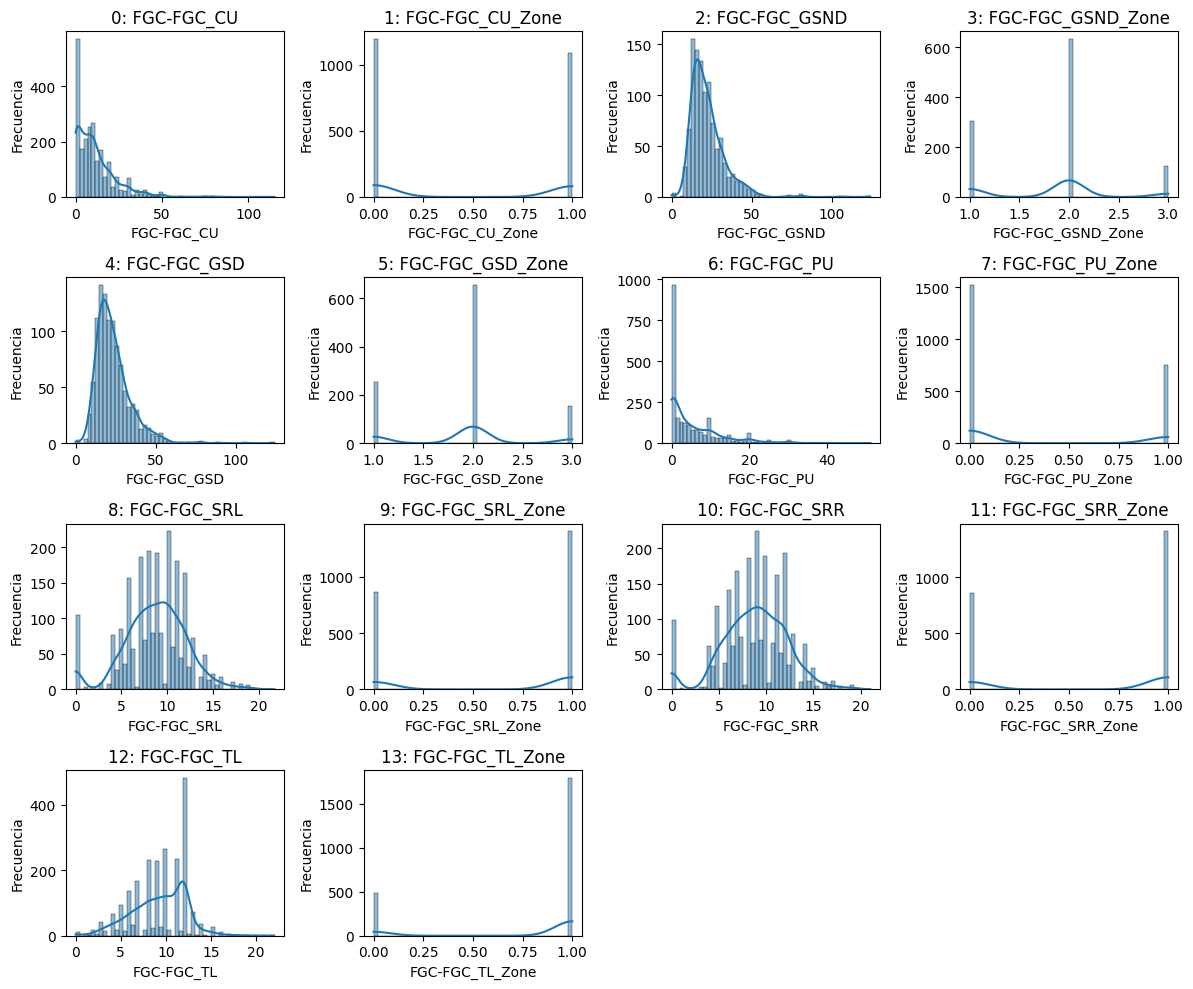

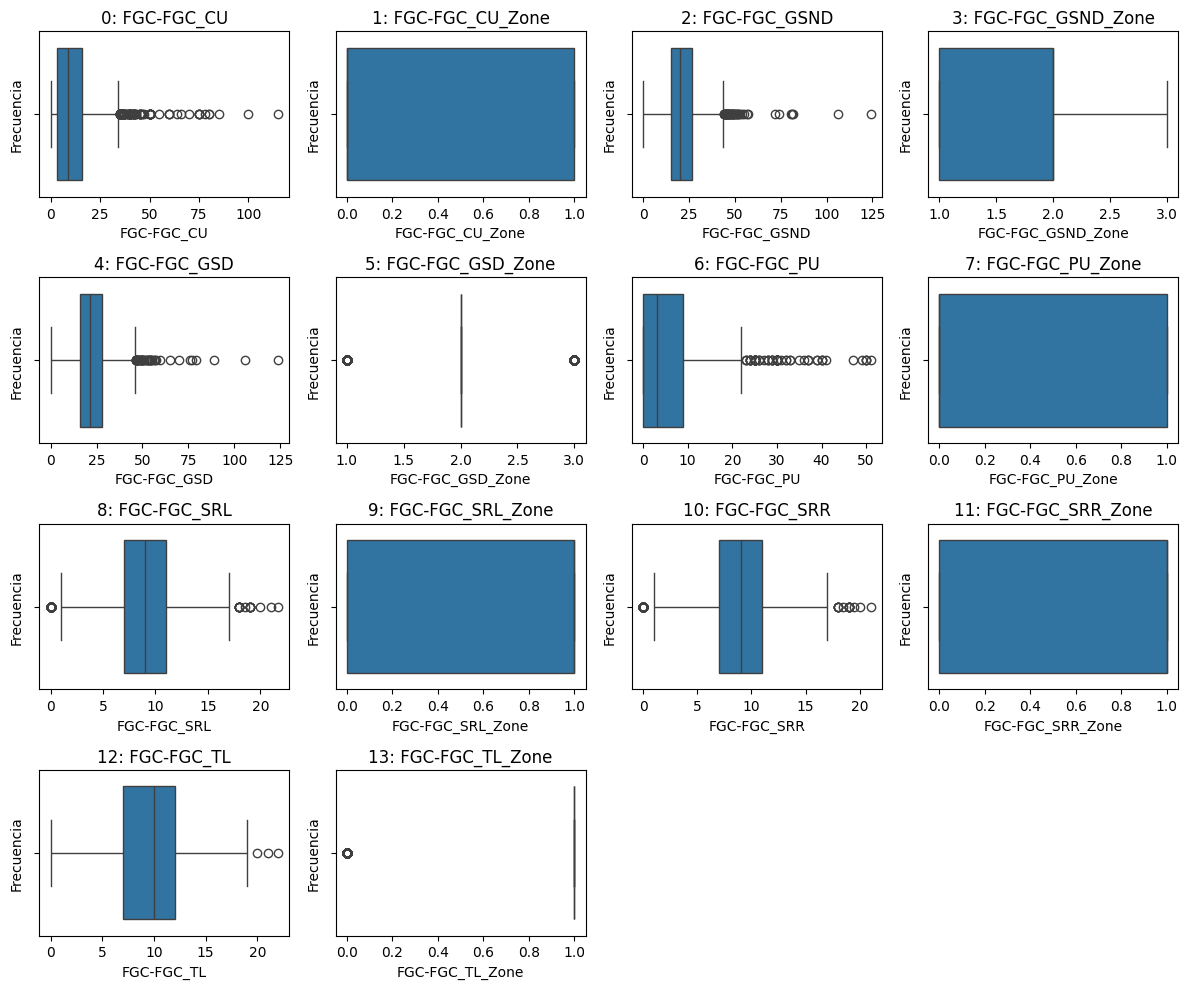

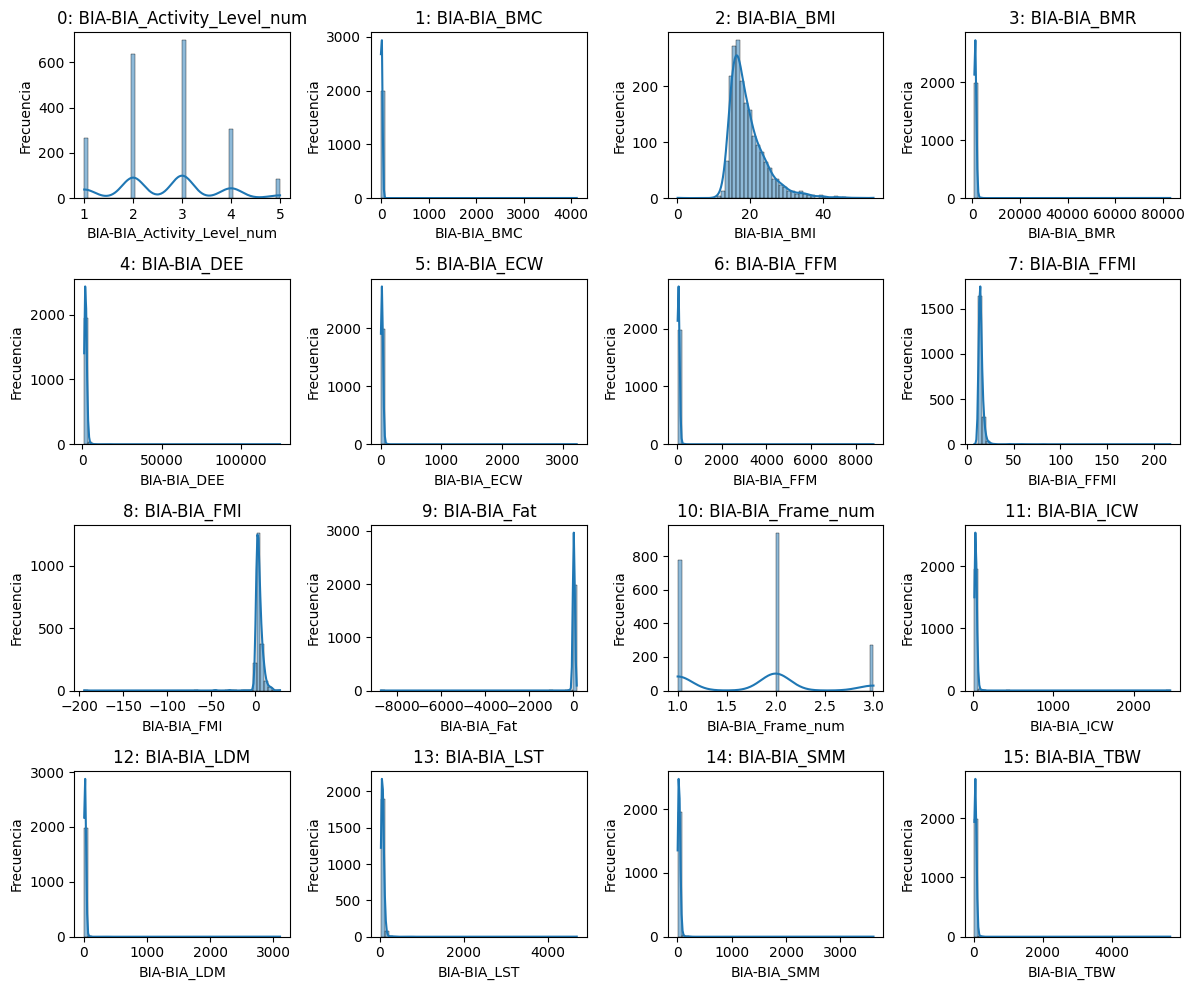

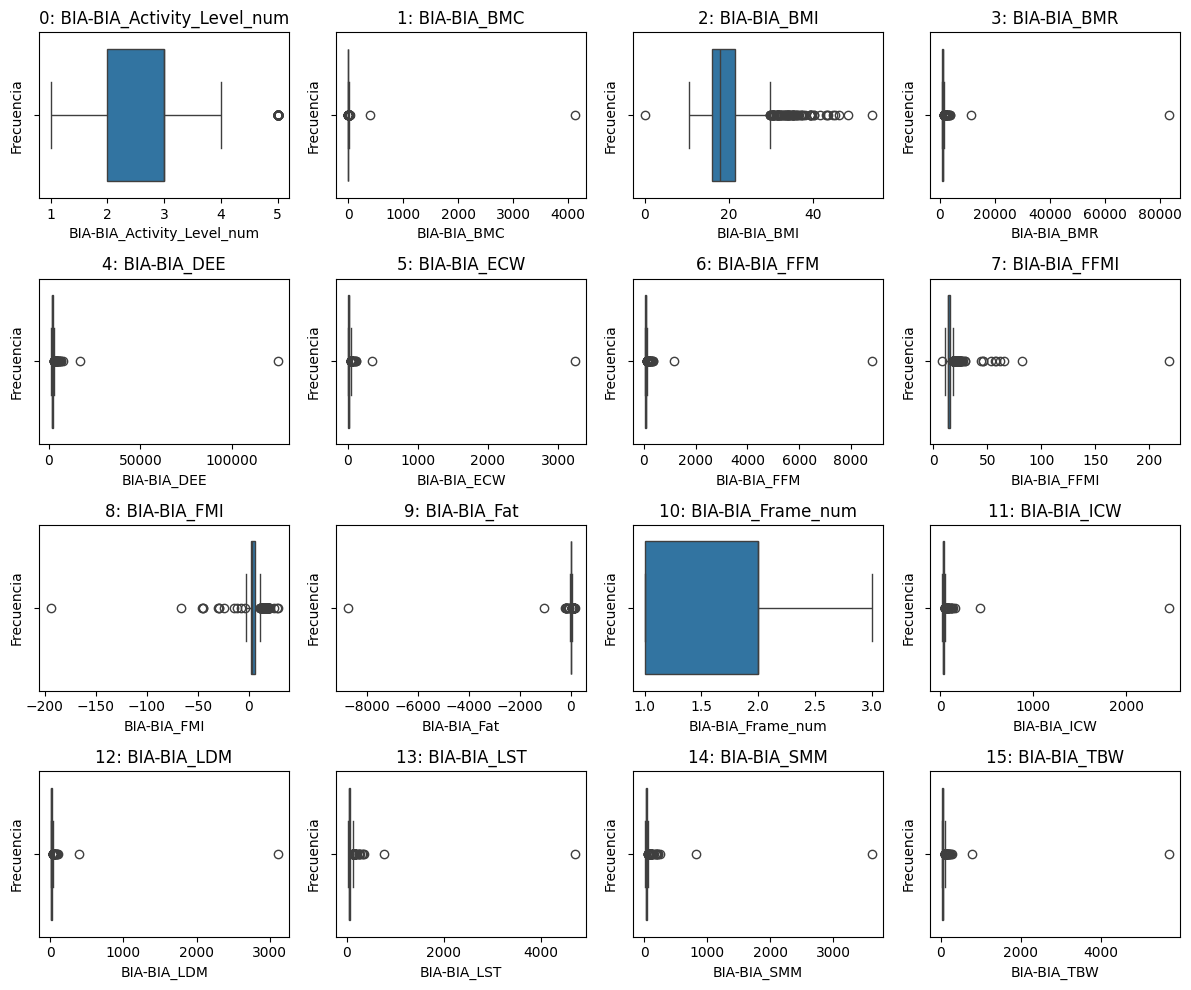

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

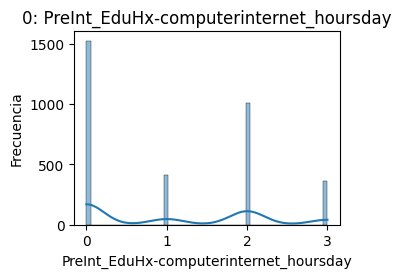

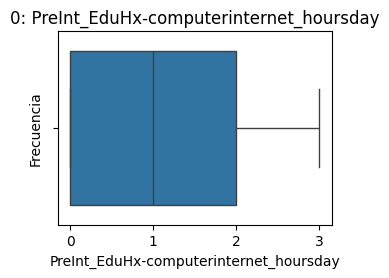

In [60]:
plot_histograms_and_box_plots(df)

# **6) Preprocesamiento de los datos**

Remover Columna 'id' no ofrece poder predictivo.

In [61]:
df_id = df['id']
df = df.drop('id', axis=1)

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,NaN,Fall,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,NaN,Fall,2.340,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.170,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Eliminación de duplicados

In [62]:
duplicates = df.duplicated()
print(f" Existen participantes duplicados: {duplicates.sum()}")

 Existen participantes duplicados: 137


Conversión y corrección de tipos de datos.

In [63]:
# Conversión variables que contienen temporada (season) de tipo object a categóricas
season_columns = []
for col in df.columns:
  if 'Season' in col:
    season_columns.append(col)

for col in season_columns:
  df[col] = df[col].astype('category')

df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,NaN,Fall,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,NaN,Fall,2.340,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.170,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
categorical_variables = ['Basic_Demos-Sex', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone',
 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone',
 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL_Zone','BIA-BIA_Activity_Level_num',
 'BIA-BIA_Frame_num', 'PreInt_EduHx-computerinternet_hoursday', 'sii']

for col in categorical_variables:
  df[col] = df[col].astype('category')

### Tratamiento de valores faltantes

#### Tratar datos númericos

In [66]:
# Se realizo una limpieza de valores faltantes en la columna sii, dado que los participantes con este valor nulo, tienen la mayoria de sus columnas tambien con valores nulos

df = df.dropna(subset=['sii'])

# Remover columnas cuyo porcentaje de perdidos sea mayor a 0.5
df = df.loc[:, df.isna().mean() < 0.50]
num_col = df.select_dtypes(include=[np.number]).columns

# Dado que las distribuciones de los datos numericos parecen Rellenar datos fatantes con el promedio
# Función para eliminar outliers y calcular el promedio para imputar datos faltantes
def eliminar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)  # Primer cuartil (25%)
    Q3 = df[columna].quantile(0.75)  # Tercer cuartil (75%)
    IQR = Q3 - Q1  # Rango intercuartílico
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtrar los datos dentro del rango permitido
    dftemp = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]
    # print(f"Promedio antes de filtrar outliers {df[columna].mean()}")
    col_mean = dftemp[columna].mean()
    df[columna] = df[columna].fillna(col_mean)

    return df

# Filtrar tipo de datos para procesar correctamente
for col in df.columns:
  if df[col].dtype == 'float64':
    eliminar_outliers(df, col)
  else:
    pass

#### Codificación de variables categoricas

In [67]:
from sklearn.preprocessing import OrdinalEncoder

# for categorical data, impute most common data
categorical_columns = []
for col in df.columns:
  enc_season = OrdinalEncoder(categories=[['Spring', 'Summer', 'Fall', 'Winter']], handle_unknown='use_encoded_value', unknown_value=np.nan)
  enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
  if 'Season' in col:
    categorical_columns.append(col)
    data = enc_season.fit_transform(df[[col]])
    df[col] = data
  elif 'Season' not in col and df[col].dtype == 'category':
    categorical_columns.append(col)
    data = enc.fit_transform(df[[col]])
    df[col] = data
  else:
    pass

In [68]:
# Imputar datos categoricos
for col in categorical_columns:
  # print(f"most common value {df[col].value_counts().idxmax()}, for {col}: \n {df[col].value_counts()}")
  # Valor mas repetido
  impute_cat = df[col].value_counts().idxmax()
  df[col] = df[col].fillna(impute_cat)

In [69]:
enc_target = OrdinalEncoder()
df['sii'] = enc_target.fit_transform(df[['sii']])

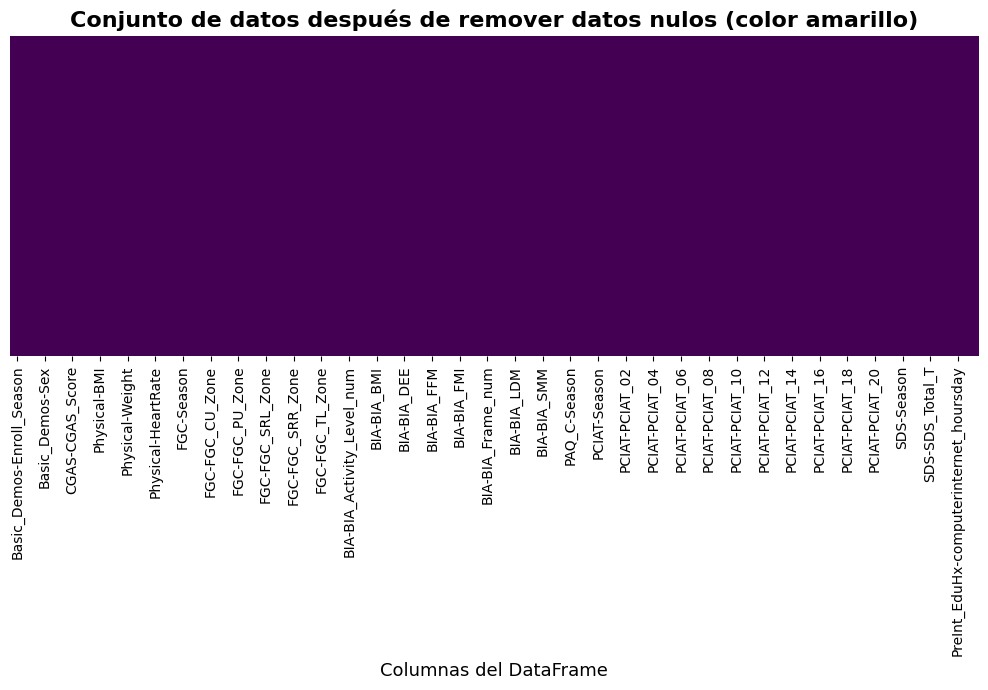

In [70]:
heatmap_missing_data(df, 'Conjunto de datos después de remover datos nulos (color amarillo)')

In [71]:
# Más de 20 minutos para ejecutar
# sns.pairplot(df, hue='sii')
# sns.pairplot(df, hue='Basic_Demos-Sex')

<Axes: >

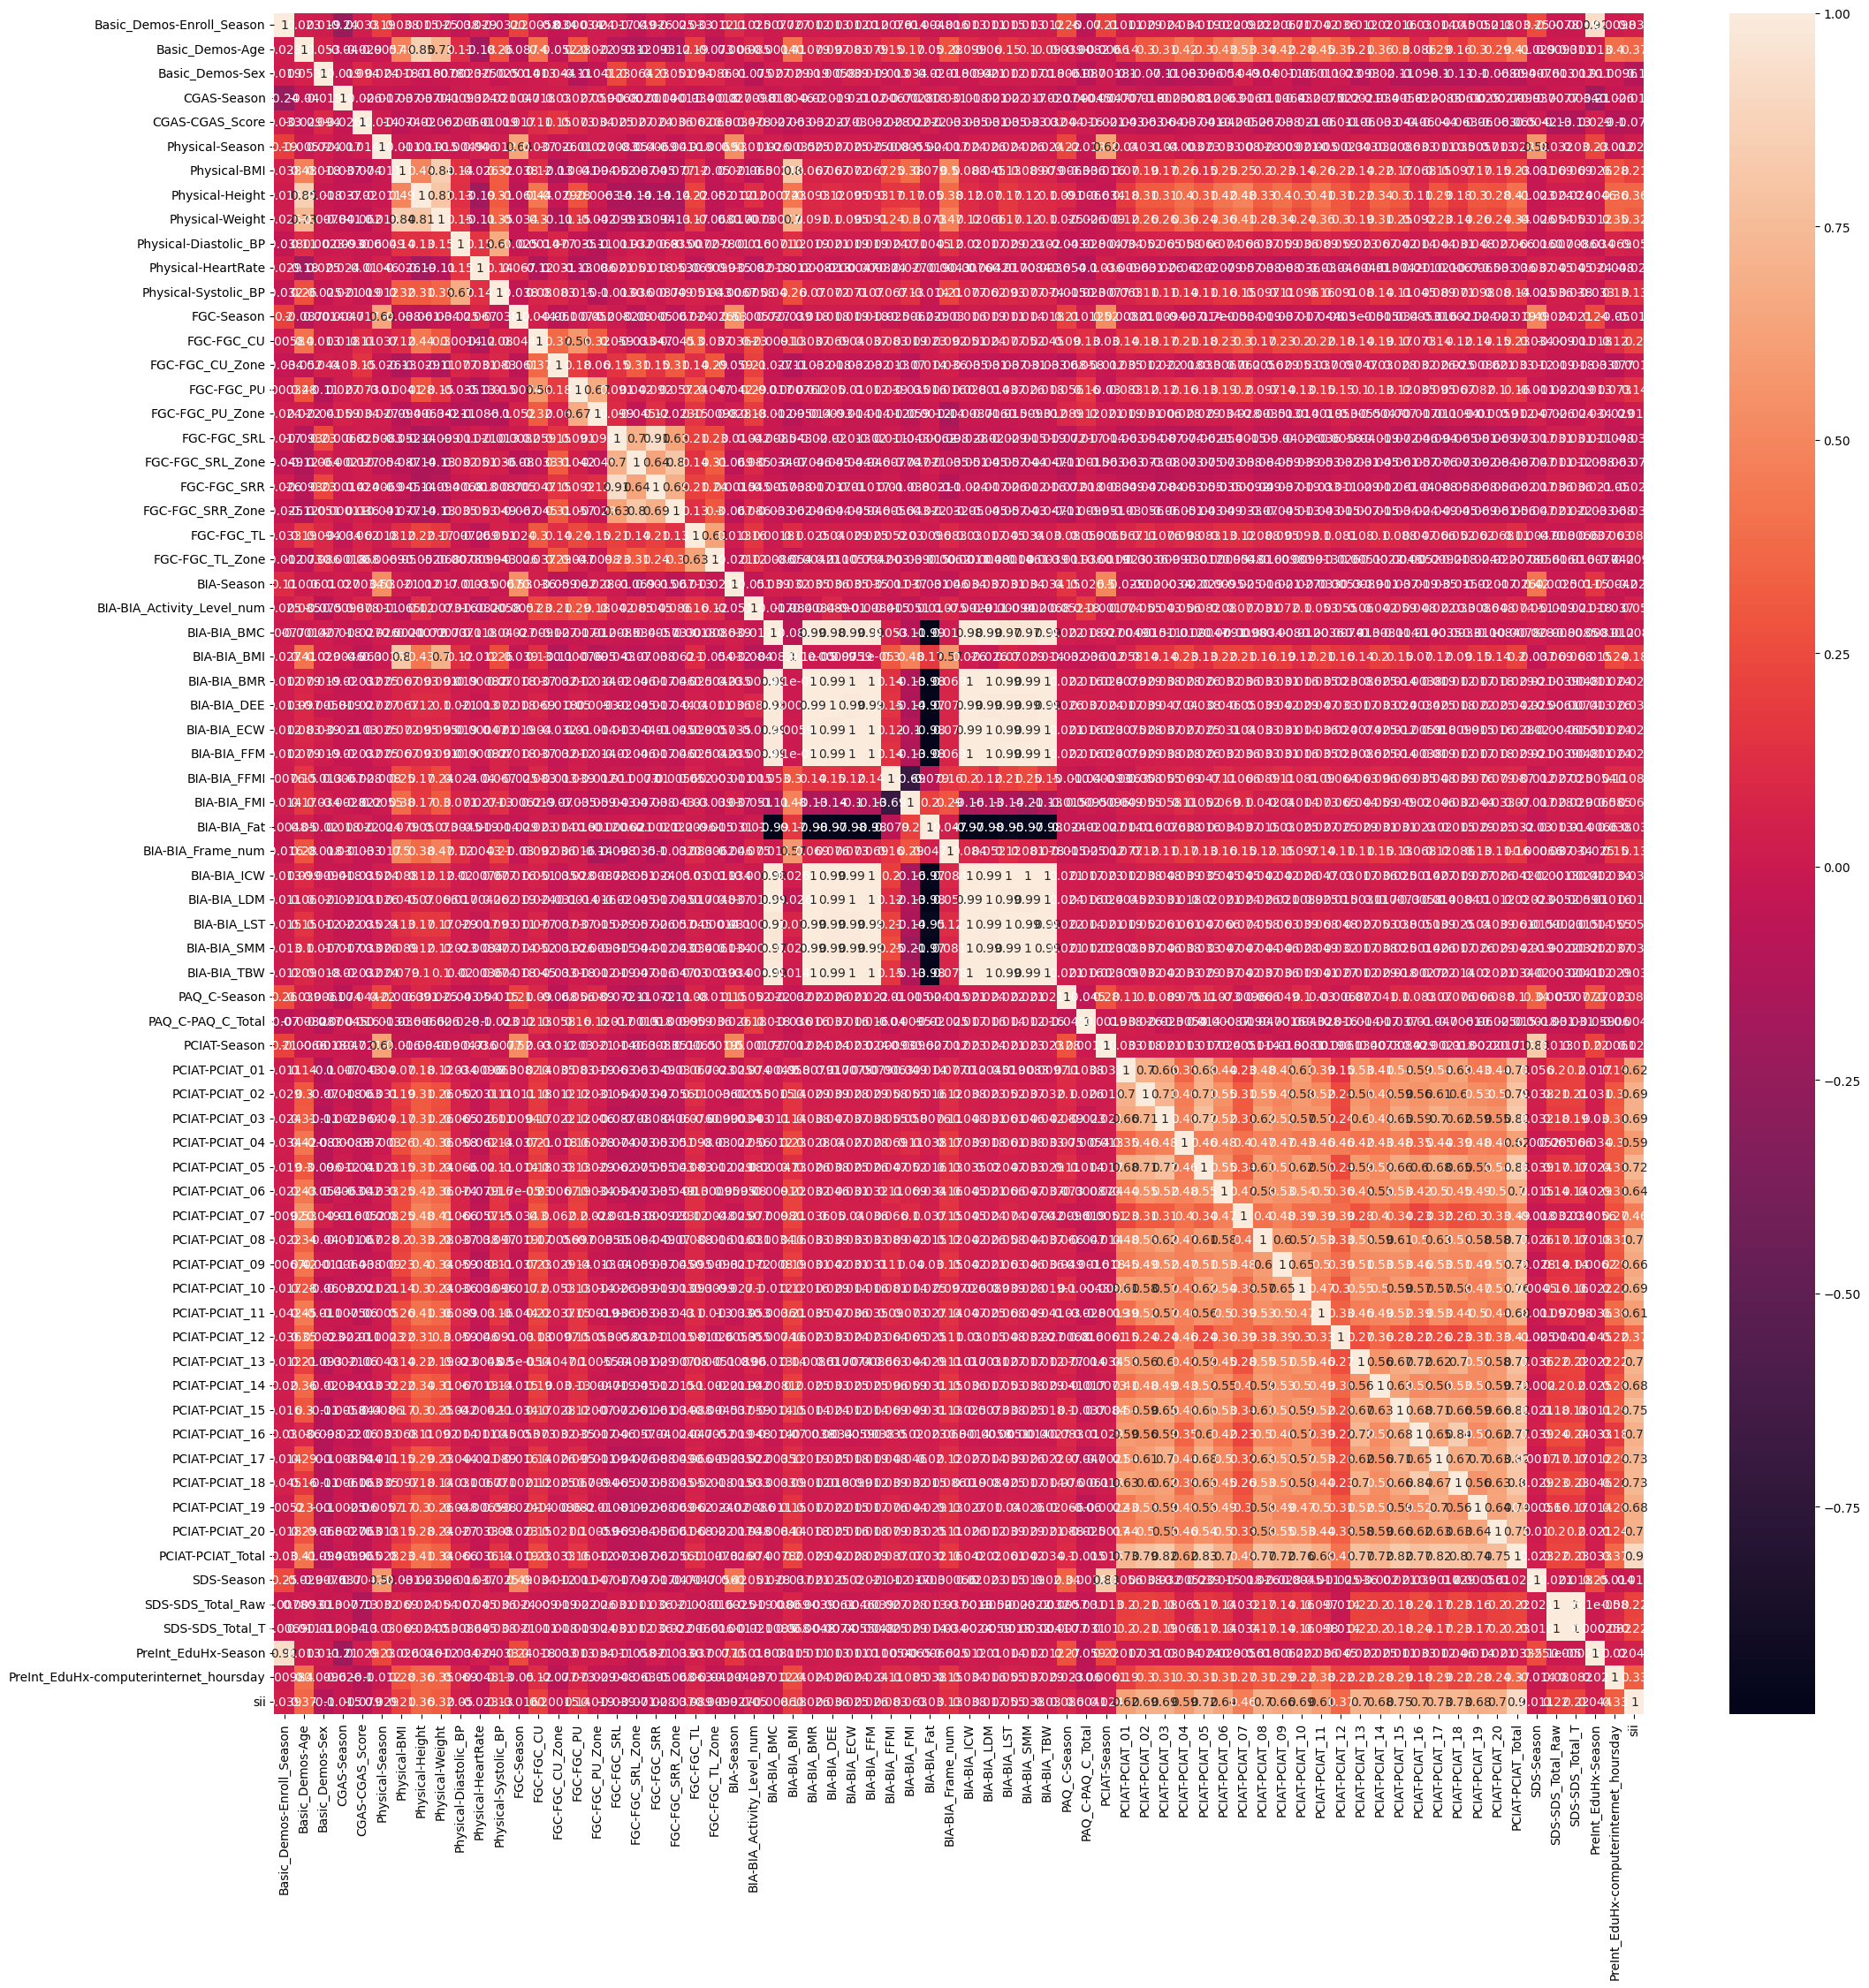

In [72]:
plt.figure(figsize=(25, 25))
sns.heatmap(df.corr(), annot=True)

# **7) Conclusiones parciales**

- La columna sii (objetivo) cuando era un valor nulo, para el/la participante, las demás columnas en su mayoría, también eran faltantes se podría inferir que el estudio no se completo por falta de interés, tiempo de los padres, tutores prefirieron no llenar las encuestas, por esta razón se realizó una operación dropna, y remover esas lineas que no ofrecían información.

- También se filtraron valores faltantes utilizando un threshold para eliminar renglones cuyos valores completos fueran menos de 50%.

- Las variables que eran un número entero(categoría 0, 1, 2, ...), y las columnas que contenían 'Season' fueron convertidas a 'category', en el caso de 'Season' se les asigno un orden especifico Spring, Summmer, Fall, Winter, para los números enteros (incluida sii), tambien se procuro el orden con Ordinal Encoder).

- Para la imputación de datos númericos, se creo una función que podia filtrar los valores atípicos, calcular el promedio y rellenar los datos faltantes, lo cual ayudaba a disminuir el impacto de los outliers.

- Para imputar datos categóricos por columna se contaron las diferentes categorías y se tomo la categoría que más se repetía para llenar los datos faltantes.

- No se eliminaron valores atípicos en esta primera etapa, ya que nuestra variable objetivo describe un uso de internet desmedido, y los valores atípicos podrían contener esa información.

- Las gráficas muestran distribuciones normales que podrían ser utilizadas por modelos paramétricos para realizar las predicciones, no se borraron valores atípicos por las razones mencionadas anteriormente.

- No se realizaron transformaciones númericas en esta parte del proyecto, tener opciones para cuando se comience la eleccion de algoritmos.


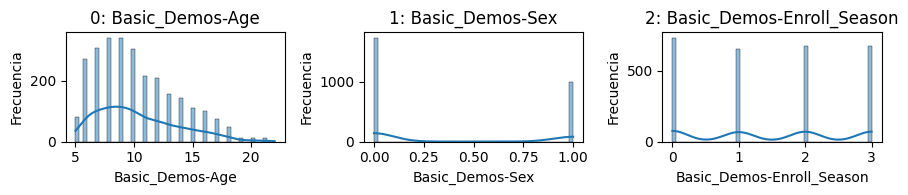

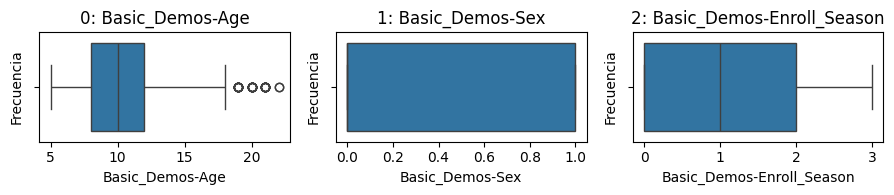

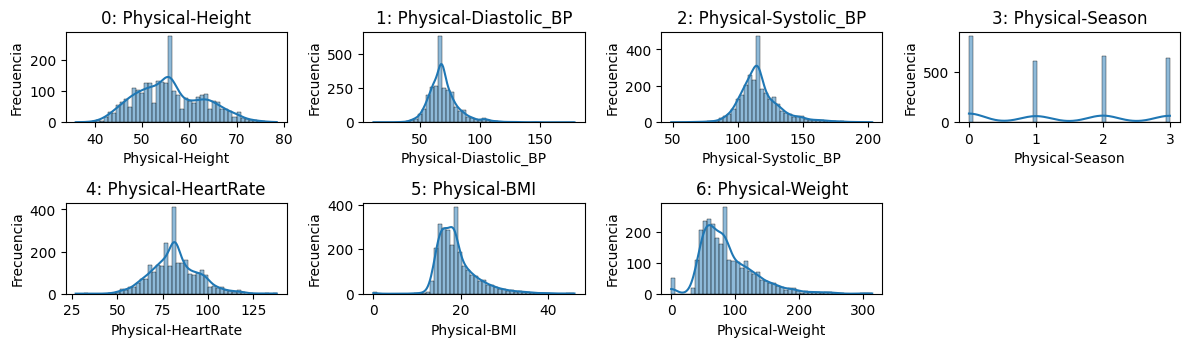

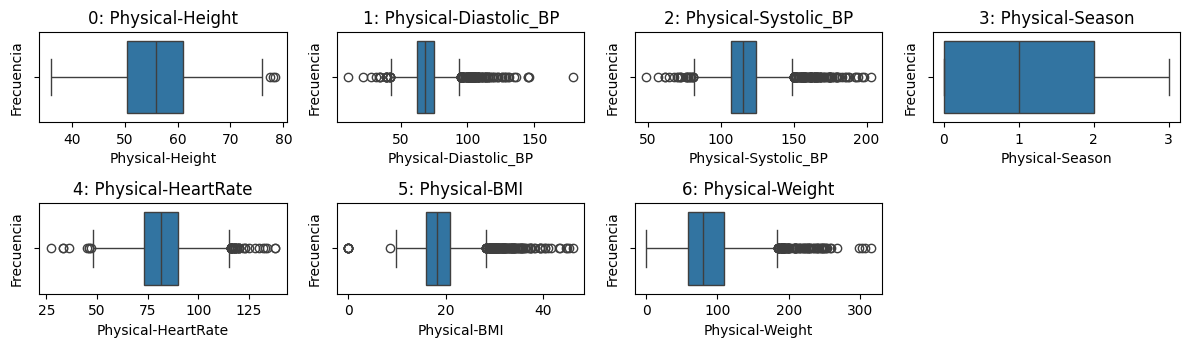

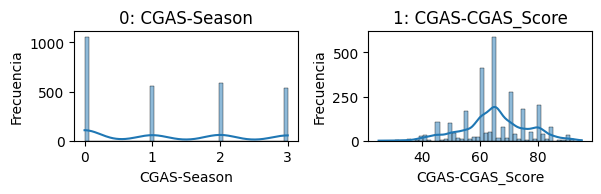

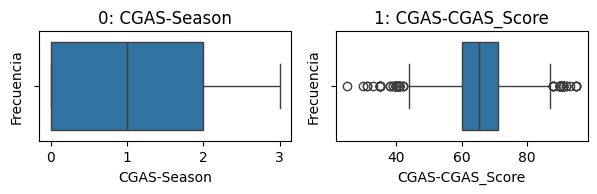

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

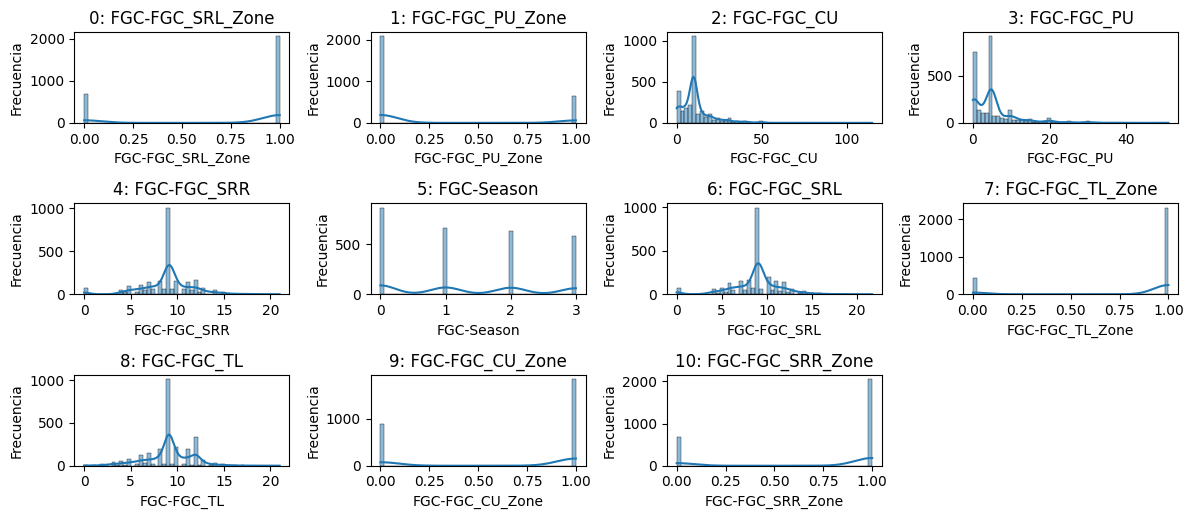

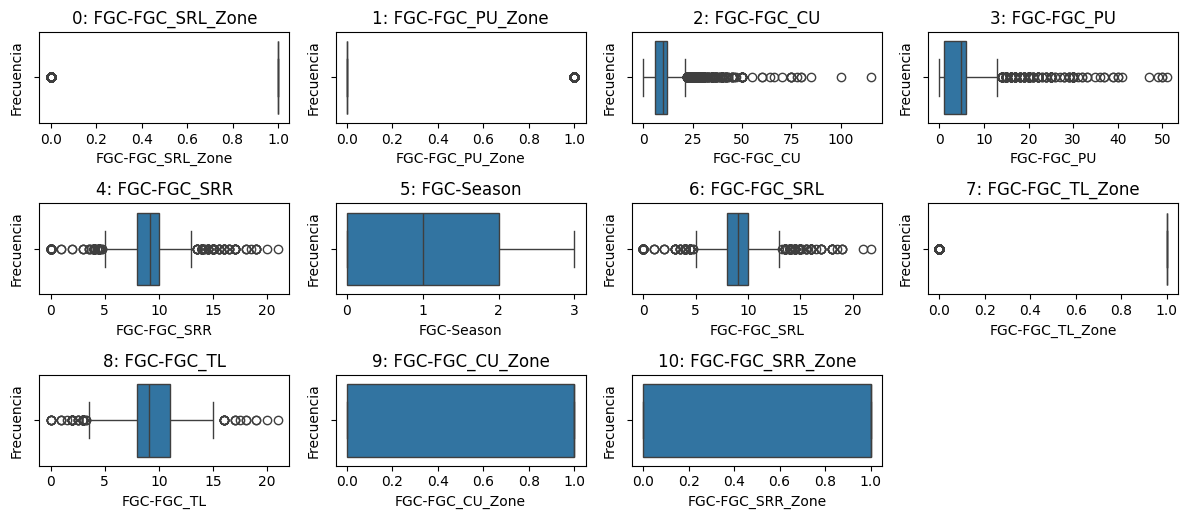

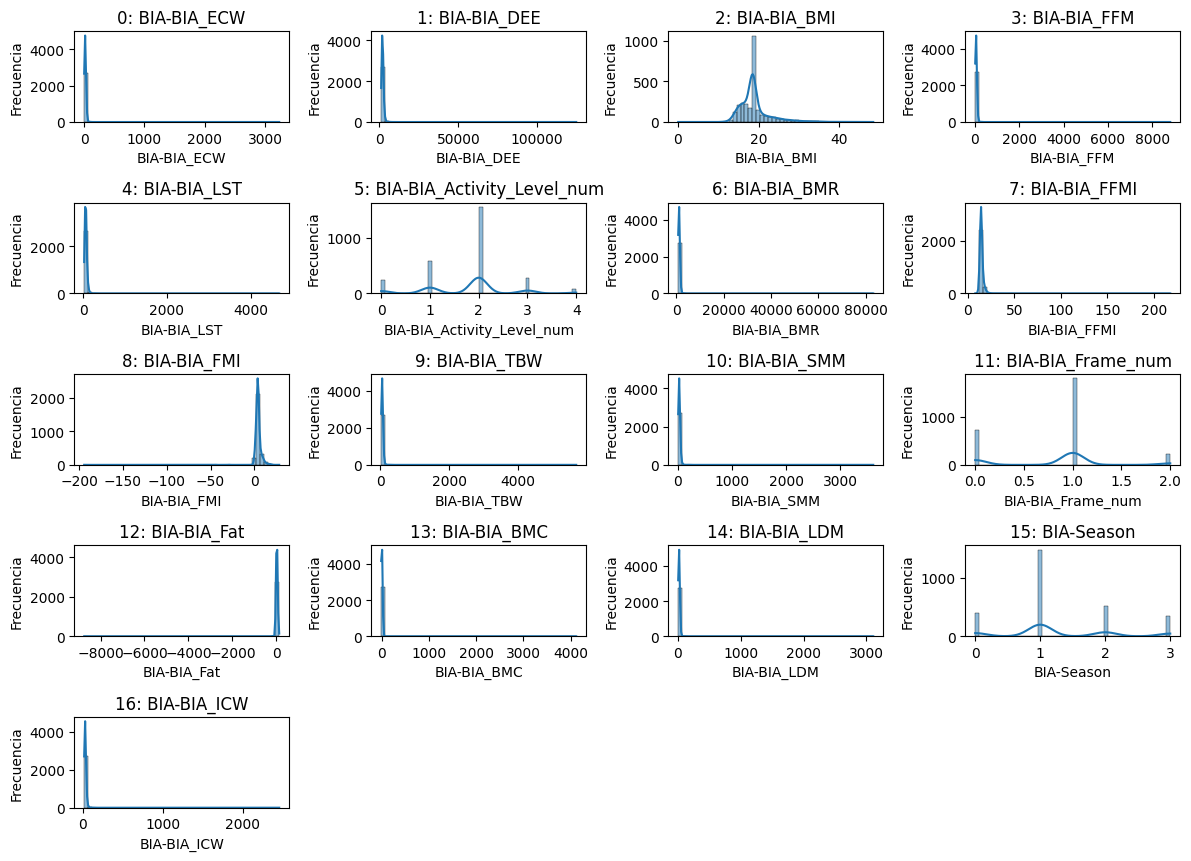

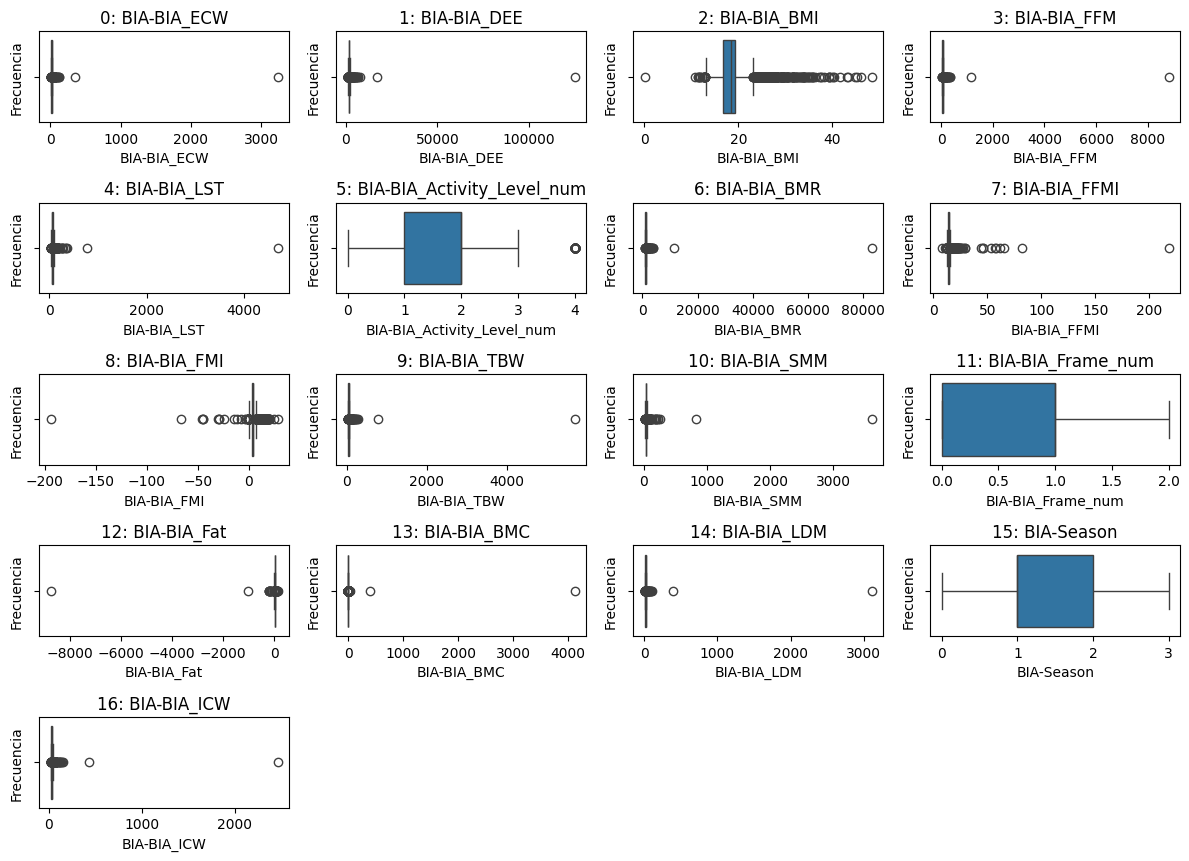

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

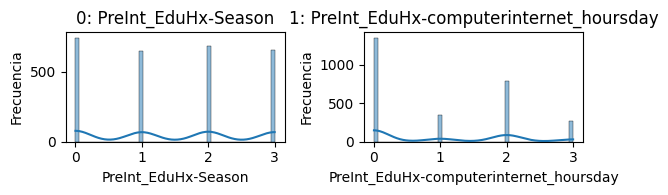

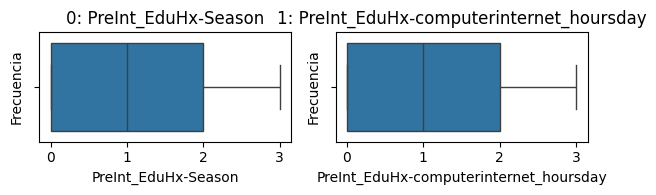

In [73]:
def hist_pdf_plot(df, sub_df):
  cols_sub_df_list = list(sub_df['Field'])
  set_sub = set(cols_sub_df_list)
  set_df = set(df.columns)
  cols = list(set_sub & set_df)

  dfp = df[cols]

  plt.figure(figsize=(12, 10))
  for i, col in enumerate(cols, 1):
      plt.subplot(6, 4, i)  # Ajustar la cantidad de subgráficos según el número de columnas
      sns.histplot(dfp[col], kde=True, bins=50)
      plt.title(f'{i-1}: {col}', fontsize=12)
      plt.xlabel(col)
      plt.ylabel('Frecuencia')

  plt.tight_layout()
  plt.show()

# # Crear los gráficos de PDF e Histograma
def box_plot(df, sub_df):
  cols_sub_df_list = list(sub_df['Field'])
  set_sub = set(cols_sub_df_list)
  set_df = set(df.columns)
  cols = list(set_sub & set_df)

  dfp = df[cols]

  plt.figure(figsize=(12, 10))
  for i, col in enumerate(cols, 1):
      plt.subplot(6, 4, i)  # Ajustar la cantidad de subgráficos según el número de columnas
      sns.boxplot(dfp[col], orient='h')
      plt.title(f'{i-1}: {col}', fontsize=12)
      plt.xlabel(col)
      plt.ylabel('Frecuencia')

  plt.tight_layout()
  plt.show()


hist_pdf_plot(df, demographics)
box_plot(df, demographics)
hist_pdf_plot(df, physical_measures)
box_plot(df, physical_measures)
hist_pdf_plot(df, assesment_scale)
box_plot(df, assesment_scale)
hist_pdf_plot(df, FGVT)
box_plot(df, FGVT)
hist_pdf_plot(df, FGC)
box_plot(df, FGC)
hist_pdf_plot(df, BEIA)
box_plot(df, BEIA)
hist_pdf_plot(df, PAQA)
box_plot(df, PAQA)
hist_pdf_plot(df, PAQC)
box_plot(df, PAQC)
hist_pdf_plot(df, PCIAT)
box_plot(df, PCIAT)
hist_pdf_plot(df, SDS)
box_plot(df, SDS)
hist_pdf_plot(df, IU)
box_plot(df, IU)

In [74]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,2.0,5,0.0,3.0,51.000000,2.0,16.877316,46.0,50.8,68.094595,81.598051,115.359746,2.0,0.0,0.0,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2.0,1.0,2.668550,16.879200,932.498000,1492.000000,8.255980,41.586200,13.817700,3.061430,9.213770,0.0,24.434900,8.895360,38.917700,19.541300,32.690900,0.0,2.590608,2.0,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,0.0,40.122001,56.600326,2.0,3.0,2.0
1,1.0,9,0.0,0.0,65.234489,2.0,14.035590,48.0,46.0,75.000000,70.000000,122.000000,2.0,3.0,0.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,3.0,1.0,2.579490,14.037100,936.656000,1498.650000,6.019930,42.029100,12.825400,1.211720,3.970850,0.0,21.035200,14.974000,39.449700,15.410700,27.055200,2.0,2.340000,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,46.000000,64.000000,1.0,0.0,0.0
2,1.0,10,1.0,2.0,71.000000,2.0,16.648696,56.5,75.6,65.000000,94.000000,117.000000,2.0,20.0,1.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,1.0,2.0,4.194034,18.513256,1155.720359,1906.321105,17.945083,65.362408,14.350412,4.075347,18.891386,1.0,29.705401,17.439323,60.863228,29.473108,48.012753,1.0,2.170000,2.0,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,2.0,38.000000,54.000000,1.0,2.0,0.0
3,3.0,9,0.0,2.0,71.000000,1.0,18.292347,56.0,81.6,60.000000,97.000000,117.000000,1.0,18.0,1.0,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,1.0,2.0,3.841910,18.294300,1131.430000,1923.440000,15.592500,62.775700,14.074000,4.220330,18.824300,1.0,30.404100,16.779000,58.933800,26.479800,45.996600,3.0,2.451000,1.0,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,1.0,31.000000,45.000000,3.0,0.0,1.0
5,0.0,13,1.0,3.0,50.000000,1.0,22.279952,59.5,112.2,60.000000,73.000000,102.000000,1.0,12.0,0.0,6.0,0.0,10.0,1.0,11.0,1.0,8.0,0.0,1.0,1.0,4.330360,30.186500,1330.970000,1996.450000,30.212400,84.028500,16.687700,13.498800,67.971500,1.0,32.914100,20.902000,79.698200,35.380400,63.126500,0.0,4.110000,1.0,3.0,3.0,3.0,0.0,2.0,1.0,0.0,2.0,2.0,1.0,0.0,1.0,3.0,3.0,2.0,1.0,3.0,1.0,2.0,1.0,34.0,1.0,40.000000,56.000000,0.0,0.0,1.0


In [75]:
df.describe()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
count,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000
mean,1.472953,10.238670,0.364401,1.217105,65.170098,1.390351,19.076865,55.897051,87.626229,69.598467,81.802819,116.961189,1.343933,11.328921,0.672880,5.493756,0.237939,8.850720,0.750731,8.958724,0.748904,9.116022,0.843567,1.289474,1.782164,6.023236,18.989759,1209.317746,2014.392321,19.824931,71.071241,14.775571,4.184670,16.861440,0.823465,31.977705,19.176647,64.945064,32.719535,51.924848,0.772295,2.590608,1.438962,2.370655,2.177762,2.399854,0.838672,2.297545,1.063690,0.585742,1.246520,1.062637,1.304793,1.685443,0.244152,1.340051,1.035505,1.499634,1.452346,1.627890,1.613636,1.158974,0.943311,27.896199,1.351608,40.912463,57.566765,1.456506,0.984649,0.580409
std,1.131565,3.427982,0.481350,1.155709,10.927273,1.150329,4.721052,7.110994,42.041682,13.132632,13.125565,16.397452,1.132107,10.072110,0.469247,6.230541,0.425899,2.752212,0.432669,2.778812,0.433723,2.474158,0.363332,0.867604,0.853463,78.982408,4.020611,1595.930768,2415.791517,62.442736,169.987883,4.903273,5.322489,169.936729,0.560665,47.930890,59.869785,92.474491,71.597986,110.226396,1.116134,0.570573,1.130240,1.672394,1.696497,1.587354,1.194585,1.703035,1.267354,1.048068,1.341108,1.257415,1.330985,1.542509,0.522582,1.409349,1.300760,1.491291,1.493411,1.442712,1.526939,1.342186,1.184854,20.338853,1.160557,9.835320,12.532719,1.127814,1.078518,0.771122
min,0.000000,5.000000,0.000000,0.000000,25.000000,0.000000,0.000000,36.000000,0.000000,11.000000,27.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.789610,0.048267,813.397000,1073.450000,1.789450,28.900400,7.864850,-194.163000,-8745.080000,0.000000,17.845000,4.635810,23.620100,11.382500,20.589200,0.000000,0.580000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,38.000000,0.000000,0.000000,0.000000
25%,0.000000,8.000000,0.000000,0.000000,60.000000,0.000000,15.916620,50.500000,58.200000,62.000000,73.000000,107.000

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2736 entries, 0 to 3958
Data columns (total 70 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Basic_Demos-Enroll_Season               2736 non-null   float64
 1   Basic_Demos-Age                         2736 non-null   int64  
 2   Basic_Demos-Sex                         2736 non-null   float64
 3   CGAS-Season                             2736 non-null   float64
 4   CGAS-CGAS_Score                         2736 non-null   float64
 5   Physical-Season                         2736 non-null   float64
 6   Physical-BMI                            2736 non-null   float64
 7   Physical-Height                         2736 non-null   float64
 8   Physical-Weight                         2736 non-null   float64
 9   Physical-Diastolic_BP                   2736 non-null   float64
 10  Physical-HeartRate                      2736 non-null   float64
 